## 📄 DecisionTreeClassifier : Car Acceptability & Iris Species Prediction

Bu proje, **Karar Ağaçları (Decision Trees)** algoritmasının hem kategorik ağırlıklı bir veri seti (Car Evaluation) hem de sürekli sayısal ağırlıklı bir veri seti (Iris) üzerinde nasıl performans gösterdiğini incelemektedir. Çalışma kapsamında **Veri Ön İşleme (Ordinal Encoding)**, **Pipeline Mimarisi** ve **Hiperparametre Optimizasyonu (GridSearchCV)** uygulanmıştır.

---
## Bölüm 1: Car Evaluation Dataset

> Bu veri setinde araçların fiziksel ve ekonomik özelliklerine bakılarak kabul edilebilirlik (class) sınıfları tahmin edilmektedir.

---

### 1.1 Veri Yükleme ve Temizleme

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("car_evaluation.csv")

In [6]:
col_names = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]

In [7]:
df.columns = col_names

In [8]:
df['doors'] = df['doors'].replace('5more', '5').astype(int)

In [9]:
df['persons'] = df['persons'].replace('more', '5').astype(int)

In [11]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


### 1.2 Keşifsel Veri Analizi (EDA)
> Kategorik değişkenlerin hedef değişken (class) ile ilişkisini countplot kullanarak frekans bazlı inceliyoruz.

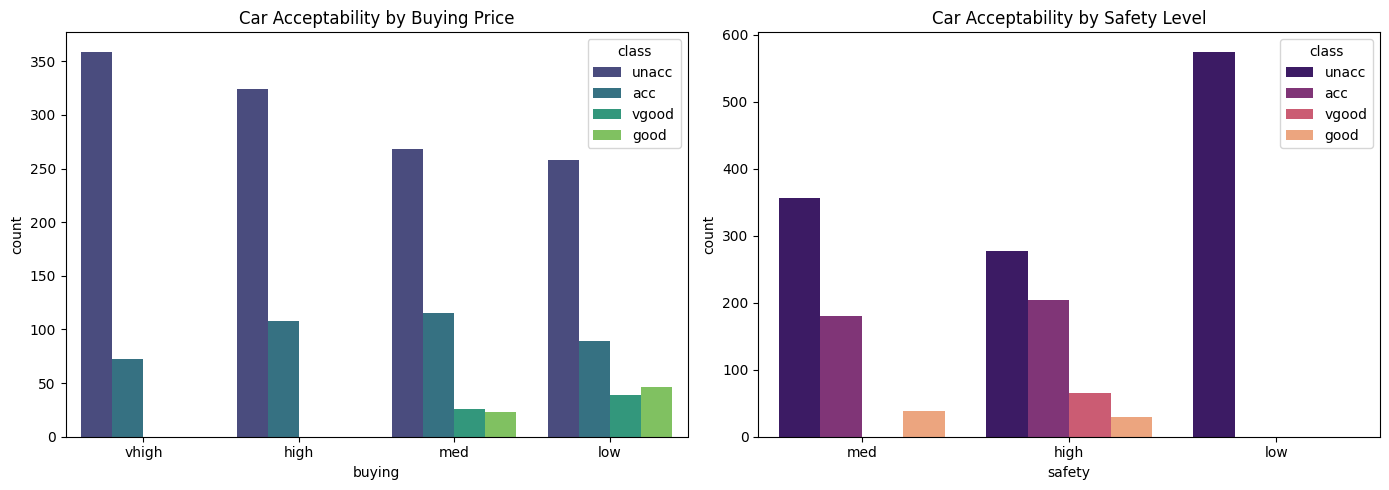

In [12]:
plt.figure(figsize=(14,5))

# Fiyatlandırma ve Sınıf İlişkisi
plt.subplot(1,2,1)
sns.countplot(data = df ,x = "buying" , hue= "class" , palette="viridis")
plt.title("Car Acceptability by Buying Price")

# Güvenlik ve Sınıf İlişkisi
plt.subplot(1,2,2)
sns.countplot(data = df , x = "safety", hue = "class" , palette = "magma") 
plt.title("Car Acceptability by Safety Level")

plt.tight_layout()
plt.show()

### 1.3 Veri Ön İşleme ve Pipeline Kurulumu (Data Preprocessing)
> Ağaç tabanlı modeller **sıralı (ordinal)** kategorik verilere duyarlıdır. Sınıflar arasındaki hiyerarşiyi **(low < med < high)** modelin anlaması için OrdinalEncoder kullanıyoruz. Tüm süreci bir Scikit-Learn Pipeline içerisine entegre ediyoruz.

In [13]:
X = df.drop('class',axis=1)
y = df["class"]

In [14]:
X_train , X_test , y_train , y_test = train_test_split(X, y, test_size=0.3 ,random_state=42)

In [15]:
categorical_cols = ["buying", "maint", "lug_boot", "safety"]
numerical_cols = ["doors", "persons"]

In [16]:
# Hiyerarşik kategoriler
ordinal_encoder = OrdinalEncoder(categories=[
    ["low", "med", "high", "vhigh"], # buying
    ["low", "med", "high", "vhigh"], # maint
    ["small", "med", "big"],         # lug_boot
    ["low", "med", "high"]           # safety
])

In [17]:
preprocessor = ColumnTransformer(transformers=[
    ('ord_encoder', ordinal_encoder, categorical_cols),
], remainder="passthrough")

In [19]:
# Uçtan uca Pipeline (Ön işleme + Model)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

### 1.4 Hiperparametre Optimizasyonu (GridSearchCV)
> Karar ağaçları **aşırı öğrenmeye (overfitting)** çok meyillidir. Düğüm bölünme kriterlerini (Gini veya Entropy) ve ağaç derinliğini **GridSearch** ile optimize ediyoruz.
* **Gini Impurity:** $Gini = 1 - \sum_{i=1}^{C} (p_i)^2$
* **Information Gain (Entropy):** $Entropy = -\sum_{i=1}^{C} p_i \log_2(p_i)$

In [20]:
# Pipeline içerisindeki classifier parametrelerine erişmek için 'classifier__' ön ekini kullanıyoruz.
param_grid = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [3, 5, 10, 15, None],
    "classifier__min_samples_split": [2, 5, 10]
}

In [21]:
grid = GridSearchCV(pipeline, param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1)

In [22]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': [3, 5, ...], 'classifier__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold 

In [23]:
print(f"En İyi Parametreler: {grid.best_params_}")

En İyi Parametreler: {'classifier__criterion': 'gini', 'classifier__max_depth': 15, 'classifier__min_samples_split': 2}


In [24]:
# Test Seti Tahmini ve Değerlendirme
y_pred = grid.predict(X_test)

In [25]:
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy Score: 0.9653179190751445

Classification Report:
               precision    recall  f1-score   support

         acc       0.96      0.92      0.94       118
        good       0.78      0.82      0.80        17
       unacc       0.98      0.99      0.99       361
       vgood       0.88      0.91      0.89        23

    accuracy                           0.97       519
   macro avg       0.90      0.91      0.90       519
weighted avg       0.97      0.97      0.97       519



### 1.5 Optimize Edilmiş Karar Ağacının Görselleştirilmesi
---

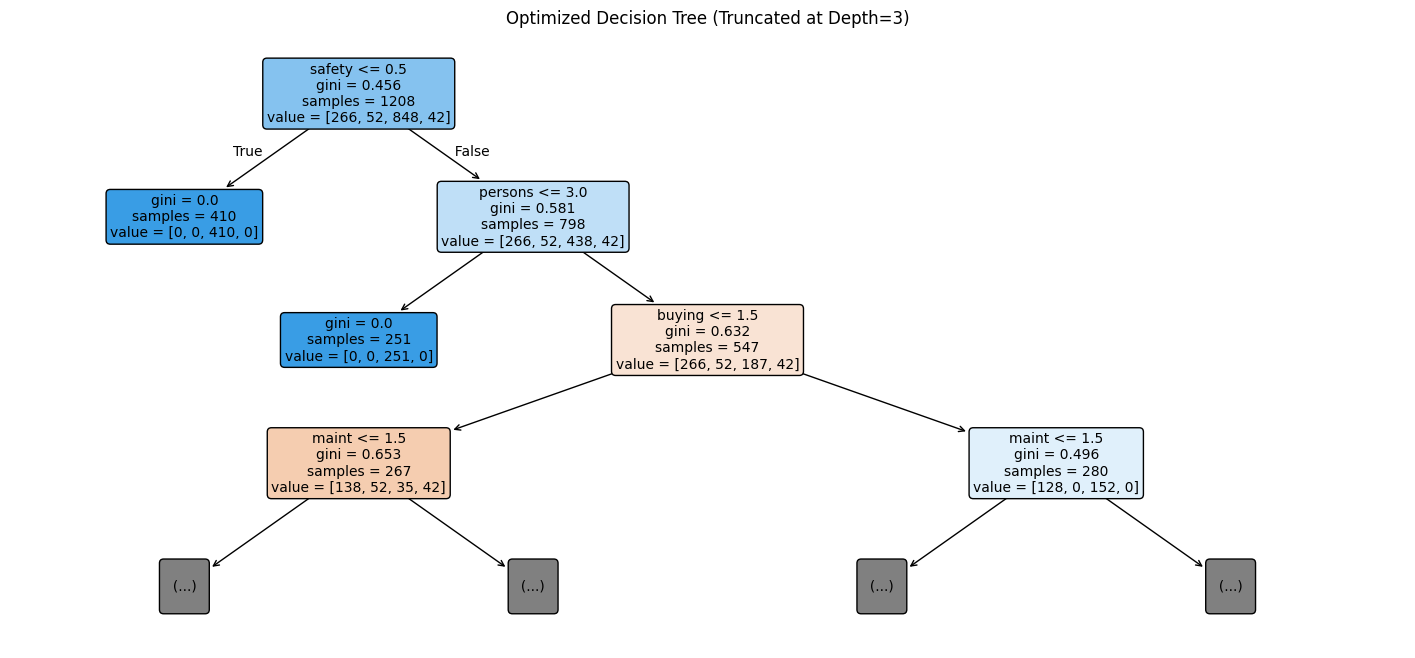

In [26]:
plt.figure(figsize=(18, 8))
# Sadece ilk 3 derinliği çizdiriyoruz ki görsel okunabilir olsun
best_tree = grid.best_estimator_.named_steps['classifier']
feature_names = categorical_cols + numerical_cols

plot_tree(best_tree, feature_names=feature_names, filled=True, rounded=True, max_depth=3, fontsize=10)
plt.title("Optimized Decision Tree (Truncated at Depth=3)")
plt.show()

---

## Bölüm 2: Iris Dataset Baseline Control

> Önceki bölümde kategorik veri manipülasyonunu test ettik. Burada ise tamamen sürekli sayısal verilerden oluşan ünlü Iris veri setinde klasik bir Karar Ağacının sınırlandırılmamış (overfitted) ve budanmış (pruned) halini kıyaslıyoruz.

---

In [27]:
df_iris = pd.read_csv("iris.csv")

In [31]:
df_iris.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [32]:
df_iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [28]:
X_iris = df_iris.drop(["Id", "Species"], axis=1)

In [29]:
y_iris = df_iris["Species"]

In [34]:
X_train_ir, X_test_ir, y_train_ir, y_test_ir = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

In [35]:
# Model 1: Sınırlandırılmamış Ağaç (Riskli)
tree_unrestricted = DecisionTreeClassifier(random_state=42)
tree_unrestricted.fit(X_train_ir, y_train_ir)
y_pred_ir1 = tree_unrestricted.predict(X_test_ir)

In [36]:
# Model 2: Budanmış Ağaç (Daha güvenli genelleme)
tree_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_pruned.fit(X_train_ir, y_train_ir)
y_pred_ir2 = tree_pruned.predict(X_test_ir)

In [37]:
print("Sınırlandırılmamış Ağaç Accuracy:", accuracy_score(y_test_ir, y_pred_ir1))
print("Budanmış Ağaç (max_depth=3) Accuracy:", accuracy_score(y_test_ir, y_pred_ir2))

Sınırlandırılmamış Ağaç Accuracy: 1.0
Budanmış Ağaç (max_depth=3) Accuracy: 1.0


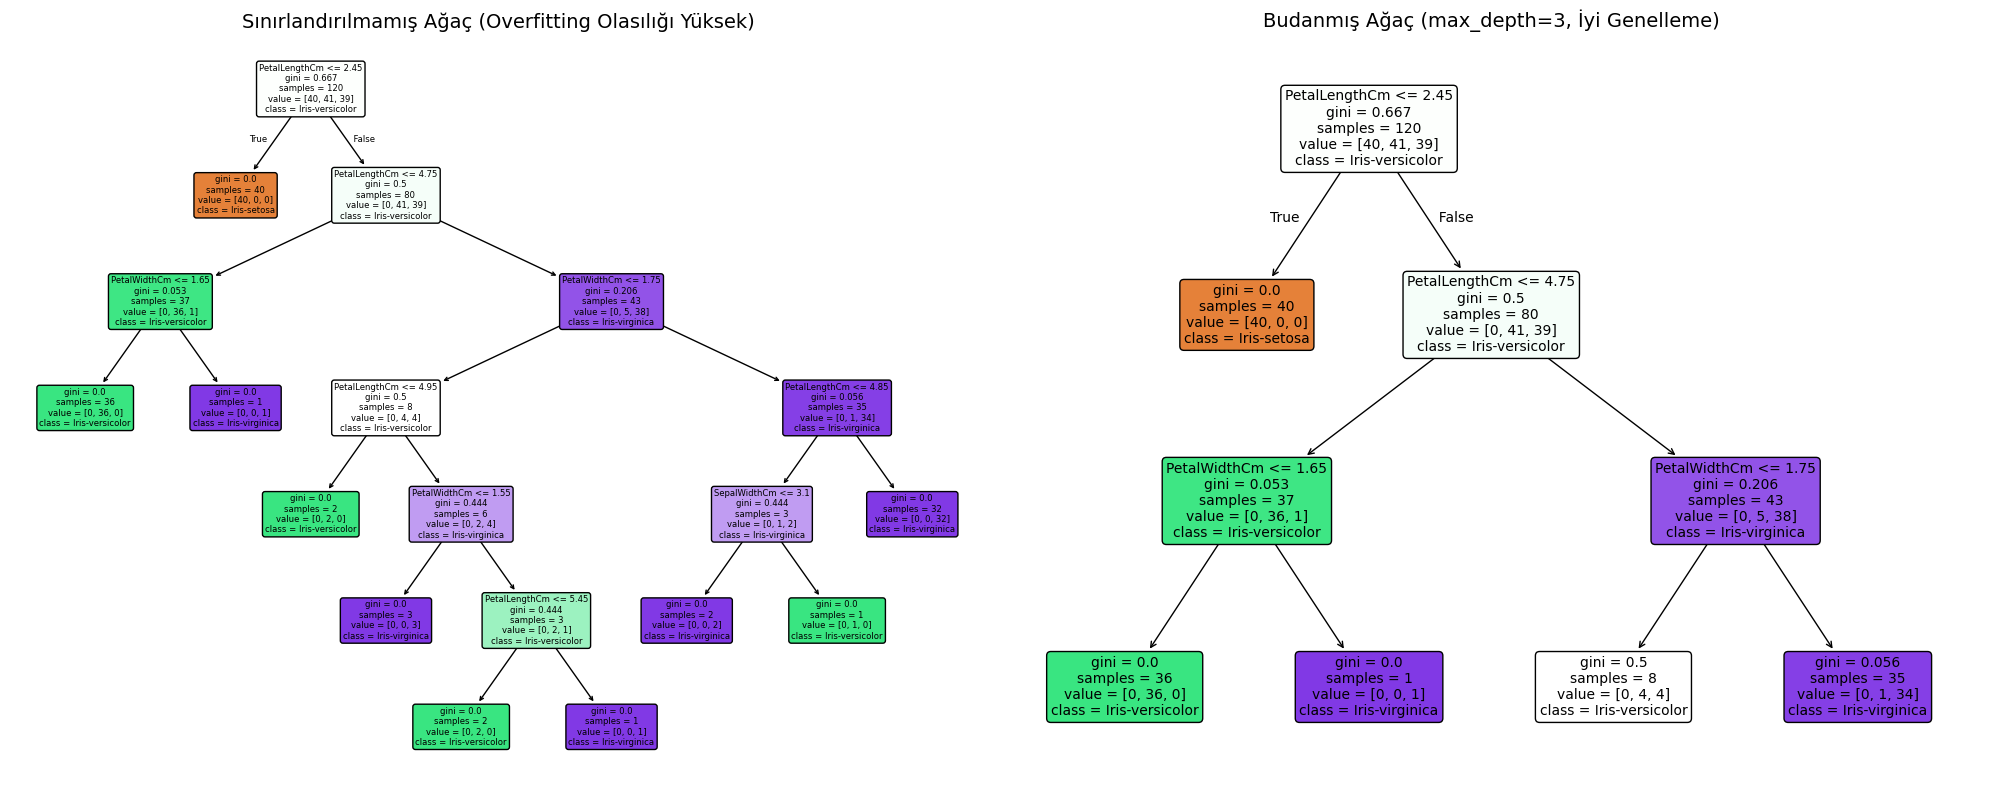

In [38]:
from sklearn.tree import plot_tree

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. Sınırlandırılmamış Ağaç Çizimi
plot_tree(tree_unrestricted, 
          feature_names=X_iris.columns, 
          class_names=tree_unrestricted.classes_,
          filled=True, rounded=True, 
          ax=axes[0])
axes[0].set_title("Sınırlandırılmamış Ağaç (Overfitting Olasılığı Yüksek)", fontsize=14)

# 2. Budanmış Ağaç Çizimi (max_depth=3)
plot_tree(tree_pruned, 
          feature_names=X_iris.columns, 
          class_names=tree_pruned.classes_,
          filled=True, rounded=True, 
          ax=axes[1])
axes[1].set_title("Budanmış Ağaç (max_depth=3, İyi Genelleme)", fontsize=14)

plt.tight_layout()
plt.show()

---
**Uzman Çıkarımı:** Iris veri seti yapısı gereği küçük ve temiz olduğu için **max_depth** sınırlandırması **doğruluğu (accuracy)** dramatik olarak düşürmemiştir. Aksine, prodüksiyon (canlı) ortamlarında her zaman **max_depth** veya **min_samples_split** uygulayarak ağacın ezberlemesini (overfitting) engellemek sektör standardıdır.